In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt
from utils.networks import Network
from utils.evaluation import  WassersteinDistance1D
from samplers.sample1d import DPSGLD1D, MYSGLD1D
from tqdm import  tqdm

plt.rcParams['font.family'] = 'Times New Roman'

# Sampling in $\mathbb{R}$

We want to sample from $\pi(x)\propto e^{-U(x)}\mathbf{1}_{\mathcal{K}}(x)$, where $\mathcal{K}= [-R, R]$ (we take $R=1$). In this example, we use $U(x)=\frac{\mu}{2}x^2+\frac{1}{4}\beta x^4-bx$ with $\mu=1.0, \beta=0.5$, and $b=1$.

In [2]:
def global_potential(x, mu=1.0, beta=0.5, b=1.0):
    f = 0.5*mu*x**2 + 0.25*beta*x**4 - b*x
    return f

In [3]:
# pi on grid
def true_distn_pi_on_grid(mu, beta, b, R, n_grid=40001):
    x = np.linspace(-R, R, n_grid)
    logp = -global_potential(x, mu, beta, b)
    logp -= logp.max()                          # Stabilize
    p_unn = np.exp(logp)
    dx = x[1] - x[0]
    Z = p_unn.sum() * dx
    pdf = p_unn / Z
    return x, pdf

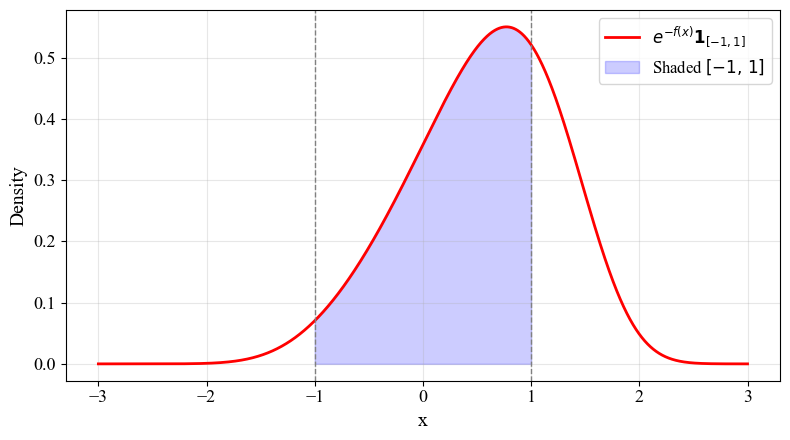

In [4]:
# Parameters 
mu, beta, b = 1.0, 0.5, 1.0
R, n_grid = 1.0, 40001
shade_a, shade_b = -R, R

x, pdf = true_distn_pi_on_grid(mu, beta, b, R, n_grid=40001)
xx = np.linspace(-3,3, n_grid)
expU_unn = np.exp(-global_potential(xx, mu, beta, b))
dx = xx[1] - xx[0]
Z_exp = expU_unn.sum() * dx
expU_pdf = expU_unn / Z_exp   # normalized on [-1,1]

fig, ax = plt.subplots(figsize=(8, 4.5))

ax.plot(xx, expU_pdf, color='red', lw=2, label=r'$e^{-f(x)}\mathbf{1}_{[-1,1]}$')
ax.fill_between(xx, expU_pdf, 0.0, where=(xx>=shade_a) & (xx<=shade_b),
                color='blue', alpha=0.2, label=r'Shaded $[-1,\,1]$')
ax.axvline(-1, color='gray', ls='--', lw=1)
ax.axvline( 1, color='gray', ls='--', lw=1)
ax.set_xlabel('x', fontsize=14)
ax.set_ylabel('Density', fontsize=14)
ax.grid(alpha=0.3)
ax.legend(fontsize=12)
ax.tick_params(axis="both", which="major", labelsize=13)
plt.tight_layout()
plt.savefig('images/target.png')
plt.show()


However, instead of $U(x)$, we use a proximal function in the potential:

$$\pi^{\gamma}(x)\propto e^{-U^{\gamma}(x)}$$

where, $U^{\gamma}(x)=\frac{\mu}{2}x^2+\frac{1}{4}\beta x^4-bx+\frac{1}{2\gamma}(x-\Pi(x))^2$, and $\Pi(x)$ is the projection on to the box $\mathcal{K}=[-1,1]$.

Once we sample, we then compute the 2-Wasserstein distance in 1 dimension based on the definition by Panaretos et. al,

$$\mathcal{W}_2^2(\mu, \nu) = \int_0^1 (F^{-1}_{\mu}(u)-F^{-1}_{\nu}(u))^2 du\approx \frac1n\sum_{k=1}^n (Q(u_k)-x^{(k)}),\quad u_k=\frac{k-\frac12}{n}$$

where, $Q=F^{-1}$ is the true quantile of the target on $[-R, R]$, and $x^{(k)}$ are stored samples at the $k$th iteration.

### True target quantile function $Q(u)$ for $\pi(x)\propto e^{-f(x)}\mathbf{1}_{[-R, R]}$

In [5]:
def make_target_quantile(R, mu=1.0, beta=0.5, b=1.0, grid_size=200_001):
    """
    Returns a collable Q(u)=F^{-1}(u) for the truncated target on [-R, R].
    Uses a dense grid + stabilized exp + trapezoidal CDF + monotone inversion
    """
    x = np.linspace(-R, R, grid_size)
    f = 0.5 * mu * x**2 + 0.25 * beta * x**4 - b * x 
    # Stabilize exp(-f)
    logw = -f 
    logw -= logw.max()
    w = np.exp(logw)
    
    # Trapezoid cumulative integral to get unnormalized CDF
    dx = x[1] - x[0]
    cdf_unnormalized = np.cumsum((w[:-1] + w[1:]) * 0.5) * dx 
    cdf_unnormalized = np.concatenate(([0.0], cdf_unnormalized))
    
    Z = cdf_unnormalized[-1]
    if not np.isfinite(Z) or Z <= 0:
        raise RuntimeError("Normalization failed; check parameters/grid size.")
    
    cdf = cdf_unnormalized / Z 
    
    # Monotone inversion
    cdf = np.maximum.accumulate(cdf)
    cdf[0] = 0.0 
    cdf[-1] = 1.0
    
    def Q(u):
        u = np.asarray(u)
        u = np.clip(u, 0.0, 1.0)
        return np.interp(u, cdf, x)
    
    return Q

In [6]:
Q = make_target_quantile(R=R)

Define the run and plot

In [7]:
def dpsgld_sampling_run(
    Q,
    size_w=100,
    N=100,
    n_steps=150,
    eta=5e-4,
    sigma_grad=0.5,
    gamma=1e-3,
    R=1.0,
    nets=("fcn", "cn", "sn", "fdn"),
    seed=121,
    figsize=(36, 16),
    logy=False
):
    fig, axes = plt.subplots(2, 4, figsize=figsize, sharey=False)
    network_names = ["Fully Connected", "Circular", "Star", "Disconnected"]

    
    agent_ids = np.sort(random.sample(range(1, size_w), 3))

    for j, (net, name) in enumerate(zip(nets, network_names)):
        ax_top = axes[0, j]
        ax_bot = axes[1, j]

        sampler = DPSGLD1D(
            size_w=size_w, N=N, n_steps=n_steps,
            eta=eta, gamma=gamma, sigma_grad=sigma_grad,
            net=net, R=R, seed=seed
        )
        history_all, X_mean_all = sampler.sample()

        my_sampler = MYSGLD1D(
            eta=eta, N=N, n_steps=n_steps,
            sigma_grad=sigma_grad, gamma=gamma,
            R=R, seed=seed
        )
        my_chain = my_sampler.sample()

        dist = WassersteinDistance1D(history_all=history_all, X_mean_all=X_mean_all)
        w2dis = dist.W2dist(Q)                         # list: size_w agents + mean at the end
        w2_my = dist.W2distSingleChain(my_chain, Q)     # 1D array length n_steps

        # ---- Top row: selected agents + mean ----
        for i in agent_ids:
            ax_top.plot(w2dis[i], label=f"Agent {i}", linewidth=3, alpha=0.9)
        ax_top.plot(w2dis[-1], label="Mean", linewidth=3, alpha=0.9, color='red')

        ax_top.set_title(name, fontsize=24)
        ax_top.grid(True, alpha=0.25)
        ax_top.set_xlabel("Iteration", fontsize=24)
        ax_top.set_ylabel(r"$\mathcal{W}_2$", fontsize=24)
        if logy:
            ax_top.set_yscale("log")
        ax_top.legend(loc="best", fontsize=18)
        ax_top.tick_params(axis="both", which="major", labelsize=18)

        # ---- Bottom row: mean vs MY ----
        ax_bot.plot(w2dis[-1], label="Mean DPSGLD", linewidth=3, alpha=0.9, color='red')
        ax_bot.plot(w2_my, label="MYSGLD", linewidth=3, alpha=0.9)

        ax_bot.grid(True, alpha=0.25)
        ax_bot.set_xlabel("Iteration", fontsize=24)
        ax_bot.set_ylabel(r"$\mathcal{W}_2$ Distance", fontsize=24)
        if logy:
            ax_bot.set_yscale("log")
        ax_bot.legend(loc="best", fontsize=18)
        ax_bot.tick_params(axis="both", which="major", labelsize=18)

    plt.tight_layout()
    plt.savefig("images/1dsampling.png")
    plt.show()

100%|██████████| 200/200 [00:00<00:00, 2692.58it/s]


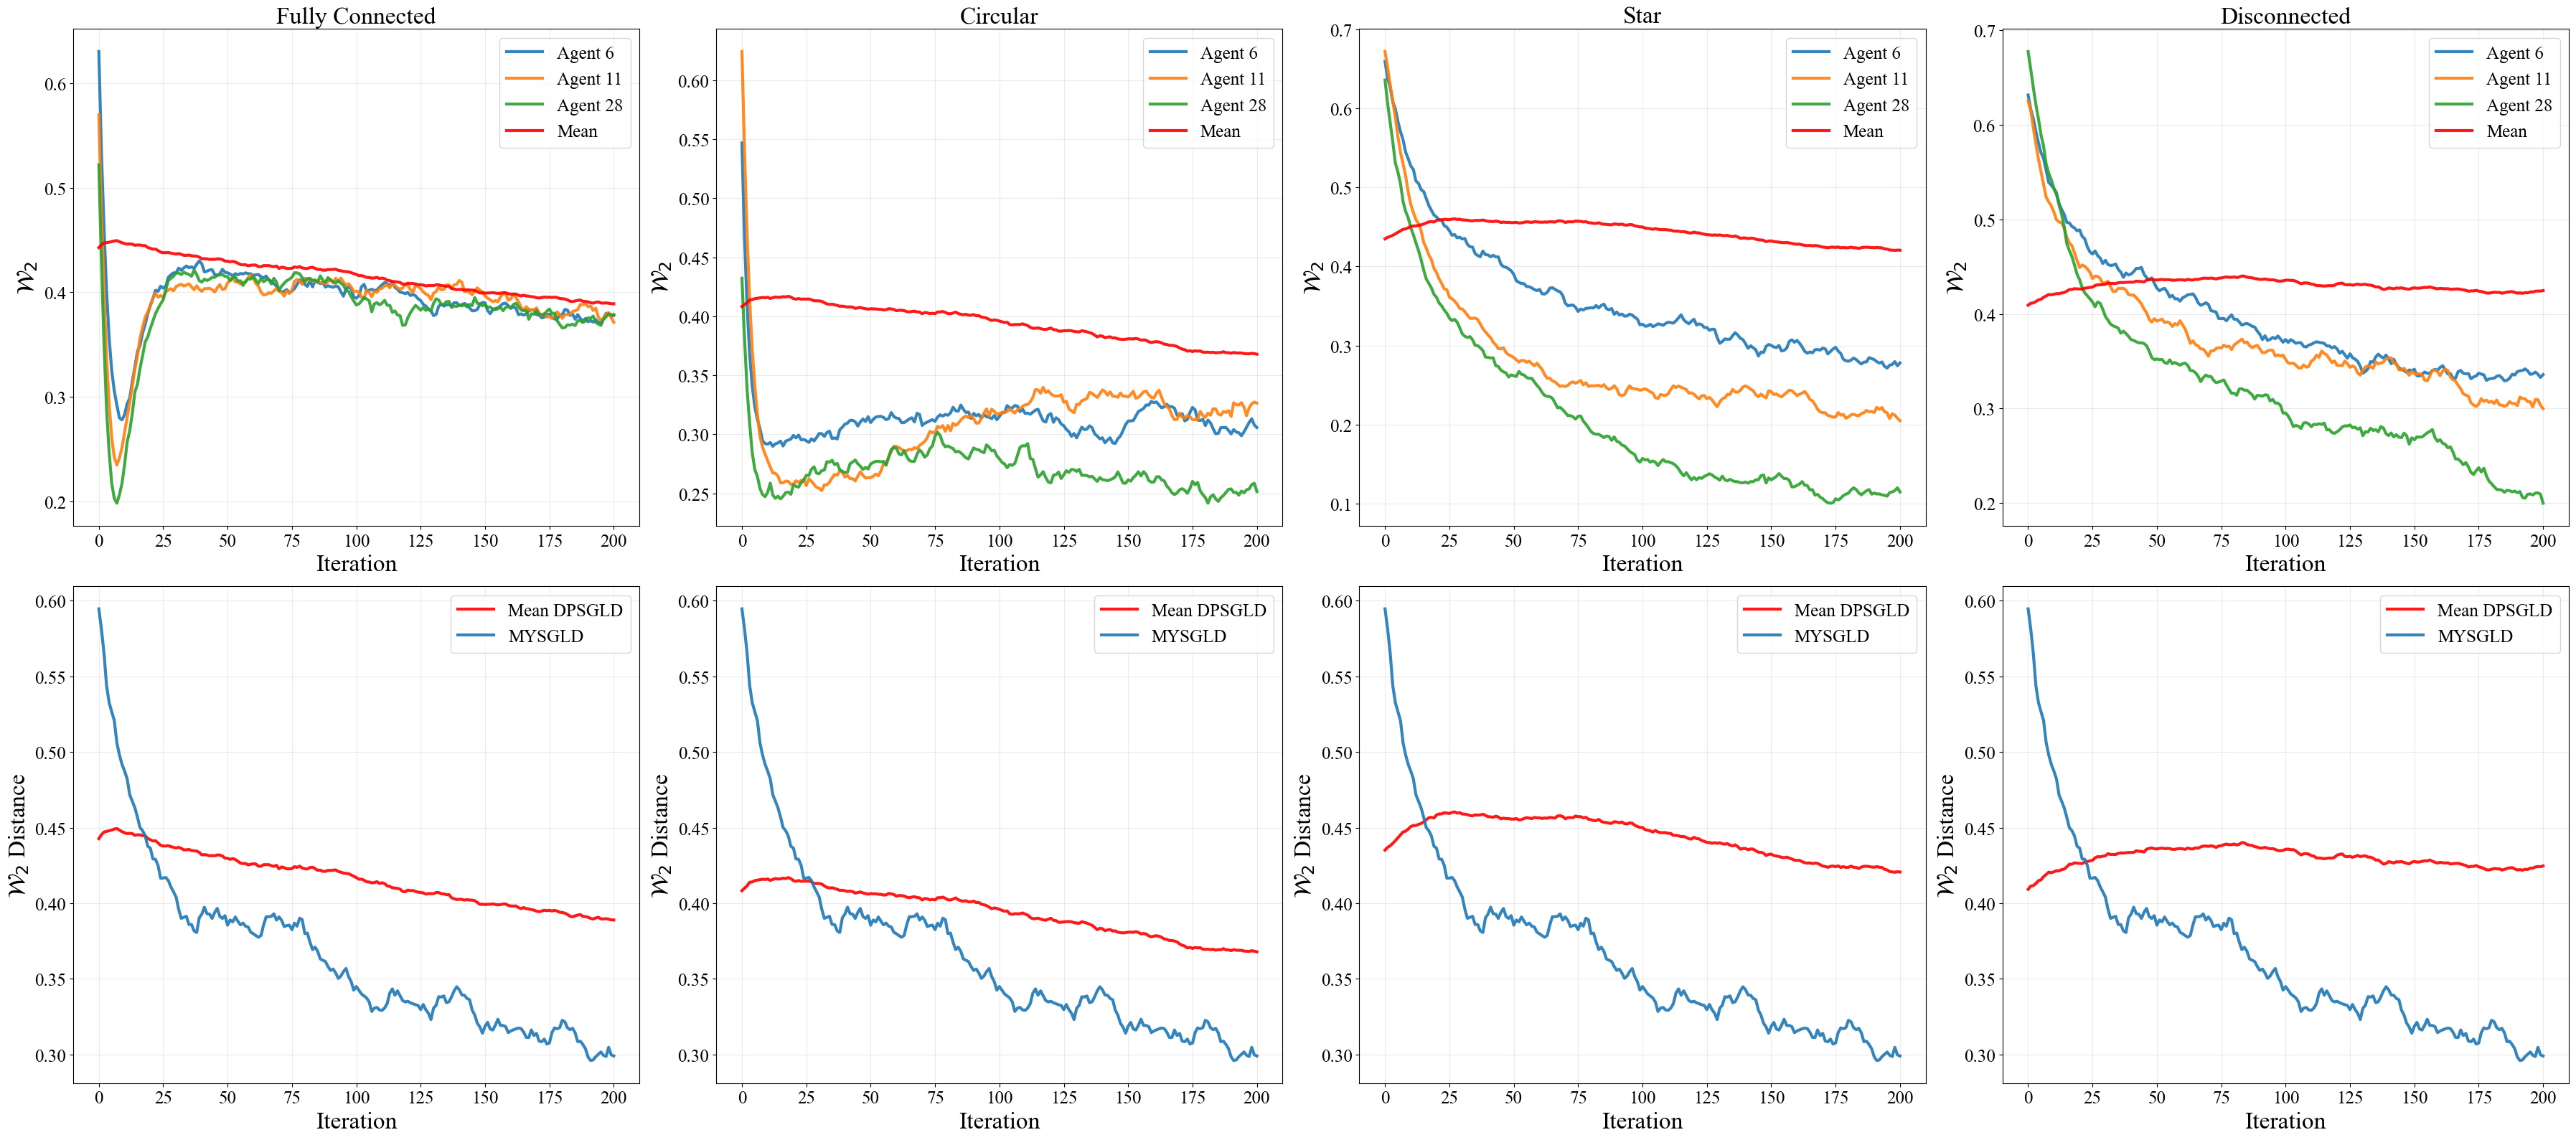

In [8]:
dpsgld_sampling_run(Q=Q, size_w=30, N=100, n_steps=200, eta=5e-4, gamma=1e-2)